In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import openpyxl

# Import Class
from pathlib import Path

In [2]:
# Set Path to current working directoryu
cwd = Path.cwd()

# Create correct filesystem paths automatically
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

In [3]:
# Test ROOT
ROOT

PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1')

In [4]:
# Create DATA_RAW
DATA_RAW = ROOT / "data" / "raw"

In [5]:
# Test DATA_RAW
DATA_RAW

PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw')

In [6]:
# Create DATA_PROCESSED
DATA_PROCESSED = ROOT / "data" / "processed"

In [7]:
# Create FIGURES
FIGURES = ROOT / "figures"

In [8]:
# Test all paths
ROOT, DATA_PROCESSED, FIGURES

(PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1'),
 PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed'),
 PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures'))

In [9]:
# Set scope in years of available data
YEAR_MIN = 2015

In [10]:
YEAR_MAX = 2023

In [11]:
YEAR_MIN, YEAR_MAX

(2015, 2023)

In [12]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures


In [13]:
# Load first raw file
RAW_DEMOGRAPHIC_ASPECTS_FILE = DATA_RAW / "Demographic-aspects-2023.xlsx"

In [14]:
# Load processed Excel to csv for merging
PCT_AGE_15_59_FILE = DATA_PROCESSED / "pct_age_15_59.csv"

In [15]:
# Create "if statement" to test for errors
if not RAW_DEMOGRAPHIC_ASPECTS_FILE.exists():
    raise FileNotFoundError

In [16]:
# Set variable for wide format
df_wide = pd.read_excel(RAW_DEMOGRAPHIC_ASPECTS_FILE, header=1)

In [17]:
# Assing pct_age dataset to a variable
ratio_clean = pd.read_csv(PCT_AGE_15_59_FILE)

In [18]:
# Inspect wide format
df_wide.head()
df_wide.columns
df_wide.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Key Demographic aspects  12 non-null     str    
 1   Unit                     10 non-null     str    
 2   2015                     11 non-null     float64
 3   2016                     11 non-null     float64
 4   2017                     11 non-null     float64
 5   2018                     11 non-null     float64
 6   2019                     11 non-null     float64
 7   2020                     11 non-null     float64
 8   2021                     11 non-null     float64
 9   2022                     11 non-null     float64
 10  2023                     11 non-null     float64
dtypes: float64(9), str(2)
memory usage: 1.4 KB


In [19]:
# Inspect pct_age data
ratio_clean.head()

,year,pct_age_15_59
0,2015,62.3
1,2016,61.8
2,2017,61.2
3,2018,60.6
4,2019,60.0


In [20]:
# Rename column and melt DataFrame

In [21]:
df_wide = df_wide.rename(columns={"Key Demographic aspects":"Indicator"})

In [22]:
df_long = df_wide.melt(
    id_vars=["Indicator", "Unit"],
    var_name="Year",
    value_name="Value"
)

In [23]:
type(df_long)

pandas.DataFrame

In [24]:
df_long["Year"] = df_long["Year"].astype(int)

In [25]:
df_long.head(25)

,Indicator,Unit,Year,Value
0,Males,Absolute,2015,51309.0
1,Females,Absolute,2015,57326.0
2,Total population,Absolute,2015,108635.0
3,Sex ratio,NaN,2015,89.5
4,Pop. per km2 land,Absolute,2015,604.0
5,Pop. 14 years and younger,%,2015,18.9
6,Pop. 60 years and older,%,2015,18.7
7,Average age,NaN,2015,NaN
8,Males,Years,2015,37.5
9,Females,Years,2015,40.1


In [26]:
df_long.dtypes

Indicator        str
Unit             str
Year           int64
Value        float64
dtype: object

In [27]:
youth_pop = df_long[df_long["Indicator"]=="Pop. 14 years and younger"]
elderly_pop = df_long[df_long["Indicator"]=="Pop. 60 years and older"]

In [28]:
youth_pop.head(), elderly_pop.head()

(                    Indicator Unit  Year  Value
 5   Pop. 14 years and younger    %  2015   18.9
 17  Pop. 14 years and younger    %  2016   18.7
 29  Pop. 14 years and younger    %  2017   18.6
 41  Pop. 14 years and younger    %  2018   18.3
 53  Pop. 14 years and younger    %  2019   18.1,
                   Indicator Unit  Year  Value
 6   Pop. 60 years and older    %  2015   18.7
 18  Pop. 60 years and older    %  2016   19.4
 30  Pop. 60 years and older    %  2017   20.1
 42  Pop. 60 years and older    %  2018   20.9
 54  Pop. 60 years and older    %  2019   21.7)

In [29]:
youth_pop["Year"]
youth_pop["Value"]

5      18.9
17     18.7
29     18.6
41     18.3
53     18.1
65     17.0
77     16.6
89     16.1
101    15.6
Name: Value, dtype: float64

In [30]:
# plt.figure(figsize=(10,6))

# plt.plot(youth_pop["Year"], youth_pop["Value"], label="Youth population")
# plt.plot(elderly_pop["Year"], elderly_pop["Value"], label="Elderly population")

# plt.legend()
# plt.title("Population aging in Aruba (2015–2023)")
# plt.xlabel("Year")
# plt.ylabel("Share of population (%)")

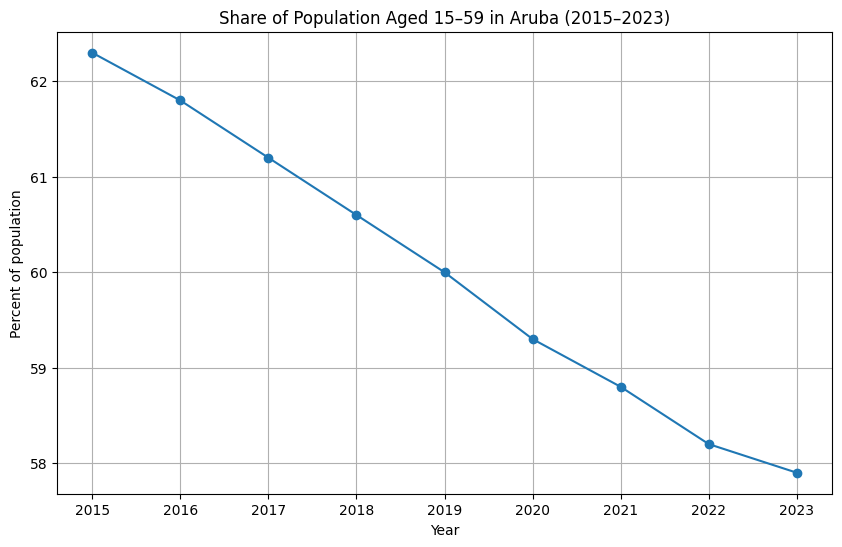

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(ratio_clean["year"], ratio_clean["pct_age_15_59"], marker="o")

plt.title("Share of Population Aged 15–59 in Aruba (2015–2023)")
plt.xlabel("Year")
plt.ylabel("Percent of population")

plt.grid(True)

plt.savefig("../figures/working_age_ratio.png", dpi=300)

plt.show()